# Technical Framework

## Core packages

In [42]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
from IPython.display import Markdown
from scipy import stats
from scipy.stats import shapiro, mannwhitneyu, ttest_ind
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.multicomp import pairwise_tukeyhsd

## Dataset acquisition

Reading the file reveals that the dataset describes the following variables:

In [44]:
df = pd.read_csv("gapminder_clean.csv").drop(columns=["Unnamed: 0"])

df_display = pd.DataFrame({"Data presented": df.columns})
Markdown(df_display.to_markdown(index=False))

| Data presented                                          |
|:--------------------------------------------------------|
| Country Name                                            |
| Year                                                    |
| Agriculture, value added (% of GDP)                     |
| CO2 emissions (metric tons per capita)                  |
| Domestic credit provided by financial sector (% of GDP) |
| Electric power consumption (kWh per capita)             |
| Energy use (kg of oil equivalent per capita)            |
| Exports of goods and services (% of GDP)                |
| Fertility rate, total (births per woman)                |
| GDP growth (annual %)                                   |
| Imports of goods and services (% of GDP)                |
| Industry, value added (% of GDP)                        |
| Inflation, GDP deflator (annual %)                      |
| Life expectancy at birth, total (years)                 |
| Population density (people per sq. km of land area)     |
| Services, etc., value added (% of GDP)                  |
| pop                                                     |
| continent                                               |
| gdpPercap                                               |

# Global wealth vs. carbon footprint

## Snapshot of 1962: The economic-environmental link

Data for 1962 is shown on a log‑scaled axis to make densely clustered countries easier to distinguish, while the tick labels remain in the original units so the values stay intuitive to read.

In [45]:
df_1962 = df[df["Year"] == 1962]
fig = px.scatter(
    df_1962,
    x="gdpPercap",
    y="CO2 emissions (metric tons per capita)",
    log_x=True,
    log_y=True,
    hover_data=["Country Name"],
    title="Global correlation between GDP and CO<sub>2</sub> emissions (1962) <br>Logarithmic Scale",
    labels={
        "CO2 emissions (metric tons per capita)": "CO<sub>2</sub> emissions (t/capita)",
        "gdpPercap": "GDP per Capita",
    },
)
fig.update_xaxes(
    type="log", range=[2, None], tickmode="auto", nticks=10, tickformat="$,~s"
)
y_ticks = [0.01, 0.1, 1, 10, 50]
fig.update_yaxes(
    type="log", tickmode="array", tickvals=y_ticks, ticktext=[str(v) for v in y_ticks]
)
fig.update_traces(
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>"  # Country
        "GDP per Capita: %{x:$,.0f}<br>"
        "CO₂ emissions: %{y:.3g} t/capita<br>"
        "<extra></extra>"
    ),
    customdata=df_1962[["Country Name"]],
)
fig.show()

A specific data point represents a suspicious outlier, warranting further inspection of the underlying data.

A review of the literature reveals the following findings. The spike in Kuwait’s CO₂ emissions in 1962—which reached world-record levels on a per capita basis—was primarily driven by the massive flaring of associated petroleum gas. During this period, the country rapidly expanded oil production following its independence (1961), but lacked the infrastructure to capture or utilize the natural gas released during extraction, resulting in it being burned off as waste. Because these vast industrial emissions were divided by a relatively small population (358,266 people at the time - according to this data set), the mathematical result was an extreme statistical anomaly that far exceeded the per capita output of even the most industrialized Western nations.

## Quantifying the correlation

To quantify the strength and direction of the linear relationship between GDP per capita and CO₂ emissions, a Pearson correlation test was conducted.

In [46]:
df_clean = df_1962[["CO2 emissions (metric tons per capita)", "gdpPercap"]].dropna()
r, p_value = stats.pearsonr(
    df_clean["CO2 emissions (metric tons per capita)"], df_clean["gdpPercap"]
)

Markdown(
    f"""
The strong positive correlation between GDP per capita and CO₂ emissions (**r = {r:.4f}**, **p = {p_value:.2e}**) shows that wealthier countries tended to emit more carbon that year.  
The next step is to scan all years and find the moment when this relationship between wealth and emissions was at its strongest.
"""
)


The strong positive correlation between GDP per capita and CO₂ emissions (**r = 0.9261**, **p = 1.13e-46**) shows that wealthier countries tended to emit more carbon that year.  
The next step is to scan all years and find the moment when this relationship between wealth and emissions was at its strongest.


4. On the unfiltered data, answer "In what year is the correlation between `'CO2 emissions (metric tons per capita)'` and `gdpPercap` the strongest?"

In [47]:
yearly_corr = (
    df.groupby("Year")[["CO2 emissions (metric tons per capita)", "gdpPercap"]]
    .corr()
    .unstack()["CO2 emissions (metric tons per capita)"]["gdpPercap"]
)
best_year = yearly_corr.idxmax()

Markdown(
    f"""
The follow‑up correlation analysis across all years shows that the strongest link between GDP per capita and CO₂ emissions emerged in {best_year}.
"""
) 


The follow‑up correlation analysis across all years shows that the strongest link between GDP per capita and CO₂ emissions emerged in 1967.


Now let’s focus and discover this period of time 

In [50]:
df_best_year = df[df["Year"] == best_year]
fig = px.scatter(
    df_best_year,
    x="gdpPercap",
    y="CO2 emissions (metric tons per capita)",
    size="pop",
    size_max=40,
    color="continent",
    log_x=True,
    log_y=True,
    hover_data=["Country Name", "Year"],
    title="CO<sub>2</sub> emissions vs GDP per capita <br>Logarithmic Scale",
    labels={
        "CO2 emissions (metric tons per capita)": "CO<sub>2</sub> emissions (t/capita)",
        "gdpPercap": "GDP per capita",
    },
)
fig.update_traces(
    marker=dict(sizemode="area", sizemin=5),
    hovertemplate=(
        "<b>%{customdata[0]}</b><br>"
        "GDP per Capita: %{x:$,.0f}<br>"
        "CO₂ emissions: %{y:.3g} t/capita<br>"
        "<extra></extra>"
    ),
    customdata=df_1962[["Country Name"]],
)
fig.update_xaxes(
    type="log", range=[2, None], tickmode="auto", nticks=5, tickformat="~s"
)
y_ticks = [0.01, 0.1, 1, 10, 50]
fig.update_yaxes(
    type="log", tickmode="array", tickvals=y_ticks, ticktext=[str(v) for v in y_ticks]
)
fig.update_layout(legend_title_text="Continents")
fig.show()

Note that the size of each circle reflects the country’s population, though the size legend has been omitted for clarity.

# Exploratory data analysis (EDA)

## Continental disparities in energy consumption

**Question 1. What is the relationship between `continent` and `'Energy use (kg of oil equivalent per capita)'`?**

Since the independent variable (continent) is categorical and the dependent variable (energy use) is quantitative, the initial analysis focused on comparing mean energy consumption across continents. Although the primary goal was to evaluate the effect of continent alone, the dataset spans multiple years, raising the possibility that temporal variation could bias the group differences. To address this concern, a deeper analysis was conducted: a two‑way ANOVA was used to test whether year or the continent‑by‑year interaction could distort the results, followed by simple‑effects tests within each year. This confirmed that the differences between continents are present both in the overall trend and consistently across all individual years.

In [59]:
df_clean = df.dropna(
    subset=["Energy use (kg of oil equivalent per capita)", "continent", "Year"]
)
model = ols(
    'Q("Energy use (kg of oil equivalent per capita)") ~ C(continent) * C(Year)',
    data=df_clean,
).fit()
anova_table = sm.stats.anova_lm(model, typ=2).reset_index()
anova_table.rename(columns={"index": "Factor"}, inplace=True)
anova_table["Conclusion"] = anova_table["PR(>F)"].apply(
    lambda p: "Reject H₀ — effect exists"
    if p < 0.05
    else "Fail to reject H₀ — no effect"
)

Markdown(
    "## Two-way ANOVA results (continent × year)\n\n"
    + anova_table.to_markdown(index=False)
)

## Two-way ANOVA results (continent × year)

| Factor               |      sum_sq |   df |         F |        PR(>F) | Conclusion                    |
|:---------------------|------------:|-----:|----------:|--------------:|:------------------------------|
| C(continent)         | 7.16055e+08 |    4 |  48.4648  |   1.59885e-36 | Reject H₀ — effect exists     |
| C(Year)              | 2.45764e+08 |    9 |   7.3929  |   2.07212e-10 | Reject H₀ — effect exists     |
| C(continent):C(Year) | 2.31637e+08 |   36 |   1.74199 |   0.00492409  | Reject H₀ — effect exists     |
| Residual             | 2.95495e+09 |  800 | nan       | nan           | Fail to reject H₀ — no effect |

In [60]:
rows = []
for year in sorted(df_clean["Year"].unique()):
    subset = df_clean[df_clean["Year"] == year]
    groups = [
        g["Energy use (kg of oil equivalent per capita)"].values
        for _, g in subset.groupby("continent")
    ]
    if len(groups) < 2:
        continue
    f, p = stats.f_oneway(*groups)
    conclusion = (
        "Fail to reject H₀ — no difference"
        if p > 0.05
        else "Reject H₀ — difference exists"
    )
    rows.append([year, round(f, 3), round(p, 6), conclusion])
simple_effects = pd.DataFrame(
    rows, columns=["Year", "F‑statistic", "p‑value", "Conclusion"]
)

Markdown(
    "## Simple effects: ANOVA within each year\n\n"
    + simple_effects.to_markdown(index=False)
)

## Simple effects: ANOVA within each year

|   Year |   F‑statistic |   p‑value | Conclusion                    |
|-------:|--------------:|----------:|:------------------------------|
|   1962 |         8.738 |  0.000664 | Reject H₀ — difference exists |
|   1967 |         9.642 |  0.000334 | Reject H₀ — difference exists |
|   1972 |         7.367 |  3.6e-05  | Reject H₀ — difference exists |
|   1977 |         8.456 |  8e-06    | Reject H₀ — difference exists |
|   1982 |         7.552 |  2.7e-05  | Reject H₀ — difference exists |
|   1987 |         8.496 |  7e-06    | Reject H₀ — difference exists |
|   1992 |         7.898 |  1.5e-05  | Reject H₀ — difference exists |
|   1997 |         7.057 |  4.9e-05  | Reject H₀ — difference exists |
|   2002 |         6.637 |  9e-05    | Reject H₀ — difference exists |
|   2007 |         6.328 |  0.000131 | Reject H₀ — difference exists |

For assessing overall differences between specific continents, the Tukey post‑hoc test was applied to all available observations. Since the two‑way ANOVA revealed a significant interaction between year and continent, an additional simple‑effects analysis (year‑specific ANOVA) was conducted. All years showed consistent differences between continents, confirming that the global Tukey results are not distorted by the temporal structure of the data and reflect genuine aggregate differences between continents.

In [61]:
df_clean = df.dropna(
    subset=["Energy use (kg of oil equivalent per capita)", "continent"]
)
tukey = pairwise_tukeyhsd(
    endog=df_clean["Energy use (kg of oil equivalent per capita)"],
    groups=df_clean["continent"],
    alpha=0.05,
)

raw = tukey.summary()
tukey_df = pd.DataFrame(raw.data[1:], columns=raw.data[0])
merged = tukey_df.iloc[:, 0] + " vs " + tukey_df.iloc[:, 1]
tukey_df.insert(0, "comparison", merged)
tukey_df = tukey_df.drop(columns=tukey_df.columns[1:3])
tukey_df = tukey_df.reset_index(drop=True)

Markdown(tukey_df.to_markdown(index=False))

| comparison          |   meandiff |   p-adj |    lower |    upper | reject   |
|:--------------------|-----------:|--------:|---------:|---------:|:---------|
| Africa vs Americas  |   1005.1   |  0      |  466.833 | 1543.37  | True     |
| Africa vs Asia      |   1168.76  |  0      |  628.253 | 1709.27  | True     |
| Africa vs Europe    |   2447.55  |  0      | 1947.38  | 2947.71  | True     |
| Africa vs Oceania   |   3281.8   |  0      | 2040.34  | 4523.25  | True     |
| Americas vs Asia    |    163.66  |  0.9256 | -384.416 |  711.736 | False    |
| Americas vs Europe  |   1442.44  |  0      |  934.114 | 1950.77  | True     |
| Americas vs Oceania |   2276.69  |  0      | 1031.92  | 3521.46  | True     |
| Asia vs Europe      |   1278.78  |  0      |  768.083 | 1789.48  | True     |
| Asia vs Oceania     |   2113.03  |  0      |  867.295 | 3358.77  | True     |
| Europe vs Oceania   |    834.252 |  0.3422 | -394.518 | 2063.02  | False    |

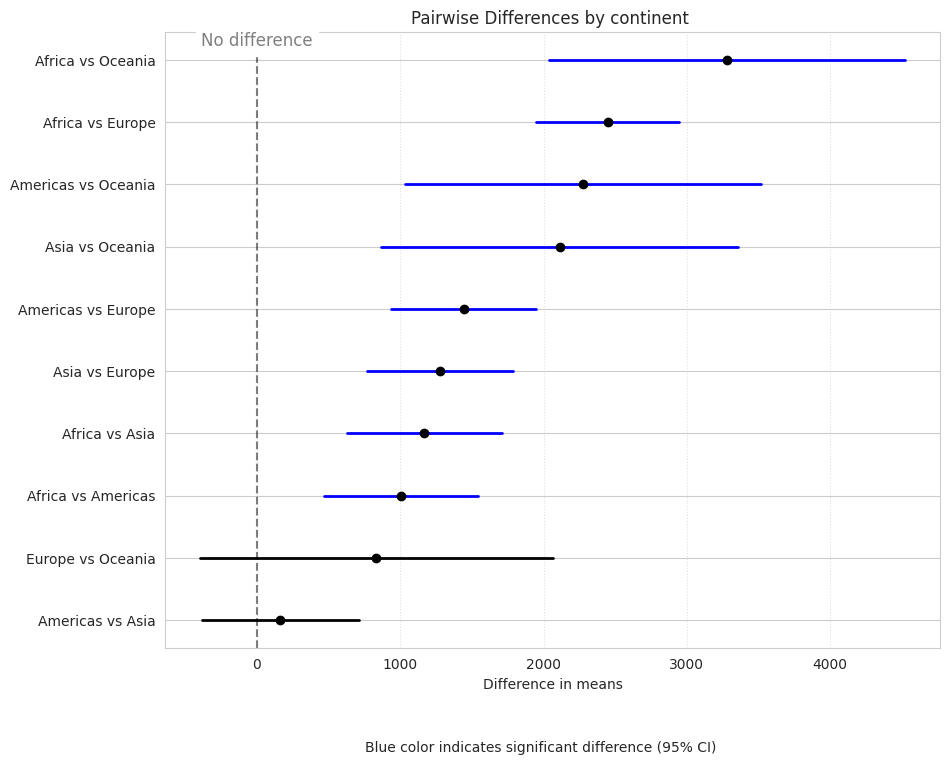

In [62]:
tukey_df = (
    pd.DataFrame(tukey.summary().data[1:], columns=tukey.summary().data[0])
    .sort_values(by="meandiff")
    .reset_index(drop=True)
)
plt.figure(figsize=(10, 8))

for i, row in tukey_df.iterrows():
    color = "blue" if row["reject"] else "black"
    plt.plot([row["lower"], row["upper"]], [i, i], color=color, linewidth=2)
    plt.plot(row["meandiff"], i, "ko")
plt.axvline(x=0, color="black", linestyle="--", alpha=0.5)
plt.text(
    0.0,
    plt.ylim()[1],
    "No difference",
    ha="center",
    va="top",
    fontsize=12,
    color="grey",
    backgroundcolor="white",
)
pairs = tukey_df["group1"] + " vs " + tukey_df["group2"]
plt.yticks(range(len(tukey_df)), pairs)
plt.xlabel("Difference in means")
plt.title("Pairwise Differences by continent ")
plt.figtext(
    0.5,
    -0.02,
    "Blue color indicates significant difference (95% CI)",
    ha="center",
    fontsize=10,
)
plt.grid(axis="x", linestyle=":", alpha=0.6)
plt.show()

The ANOVA results demonstrate that continent is a decisive factor shaping energy consumption levels, both in the overall dataset and consistently across all individual years. A follow‑up Tukey test showed that almost all continent pairs differ significantly, with the exceptions of the Oceania–Europe and Asia–Americas pairs, whose energy consumption levels remain statistically similar in the aggregate trend and within each examined year.

2. Is there a significant difference between Europe and Asia with respect to `'Imports of goods and services (% of GDP)'` in the years after 1990? (Stats test needed)

In [53]:
from scipy.stats import shapiro

# Filter data for Asia and Europe after 1990
df_asia_europe = df[(df['Year'] > 1990) & (df['continent'].isin(['Asia', 'Europe']))].copy()

# Separate data by continent
asia_imports = df_asia_europe[df_asia_europe['continent'] == 'Asia']['Imports of goods and services (% of GDP)'].dropna()
europe_imports = df_asia_europe[df_asia_europe['continent'] == 'Europe']['Imports of goods and services (% of GDP)'].dropna()

# Perform Shapiro-Wilk test for each continent

stat_asia, p_asia = shapiro(asia_imports)
stat_europe, p_europe = shapiro(europe_imports)

print("Shapiro-Wilk Normality Test Results:")
print(f"\nAsia:")
print(f"  Test statistic: {stat_asia:.6f}")
print(f"  p-value: {p_asia:.6e}")
print(f"  Normal: {'Yes' if p_asia > 0.05 else 'No'}")

print(f"\nEurope:")
print(f"  Test statistic: {stat_europe:.6f}")
print(f"  p-value: {p_europe:.6e}")
print(f"  Normal: {'Yes' if p_europe > 0.05 else 'No'}")

Shapiro-Wilk Normality Test Results:

Asia:
  Test statistic: 0.854897
  p-value: 2.309692e-08
  Normal: No

Europe:
  Test statistic: 0.929049
  p-value: 1.363335e-05
  Normal: No


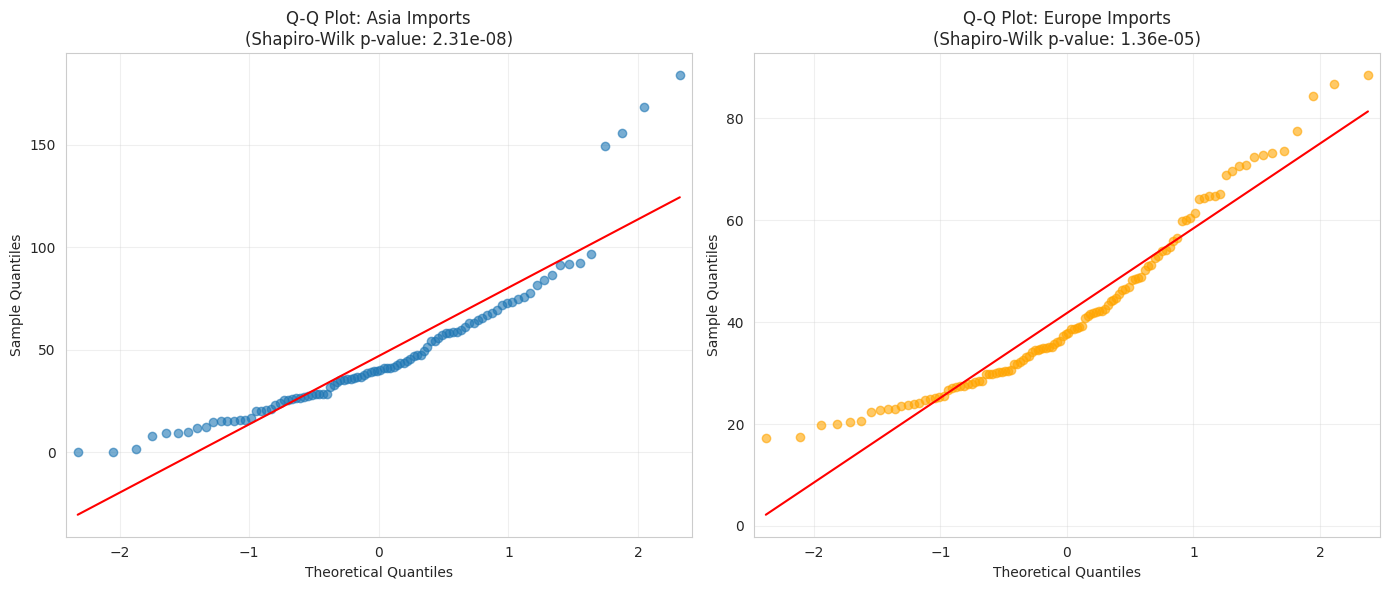

In [54]:
import statsmodels.api as sm
p_asia = stats.shapiro(asia_imports.dropna())[1]
p_europe = stats.shapiro(europe_imports.dropna())[1]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sm.qqplot(asia_imports.dropna(), line='s', ax=axes[0], alpha=0.6)
axes[0].set_title(f'Q-Q Plot: Asia Imports\n(Shapiro-Wilk p-value: {p_asia:.2e})')
axes[0].grid(alpha=0.3)

sm.qqplot(europe_imports.dropna(), line='s', ax=axes[1], alpha=0.6)
axes[1].get_lines()[0].set_markerfacecolor('orange') 
axes[1].get_lines()[0].set_markeredgecolor('orange')

axes[1].set_title(f'Q-Q Plot: Europe Imports\n(Shapiro-Wilk p-value: {p_europe:.2e})')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [55]:
# Perform Mann-Whitney U test (non-parametric alternative to t-test)
stat_mw, p_value_mw = stats.mannwhitneyu(asia_imports, europe_imports, alternative='two-sided')
print(f"Mann-Whitney U Test Results:")
print(f"Test statistic: {stat_mw:.1f}")
print(f"p-value: {p_value_mw:.4f}")
print(f"\nConclusion: {'Significant difference' if p_value_mw < 0.05 else 'No significant difference'} between Asia and Europe imports (α=0.05)")

Mann-Whitney U Test Results:
Test statistic: 5707.0
p-value: 0.7867

Conclusion: No significant difference between Asia and Europe imports (α=0.05)


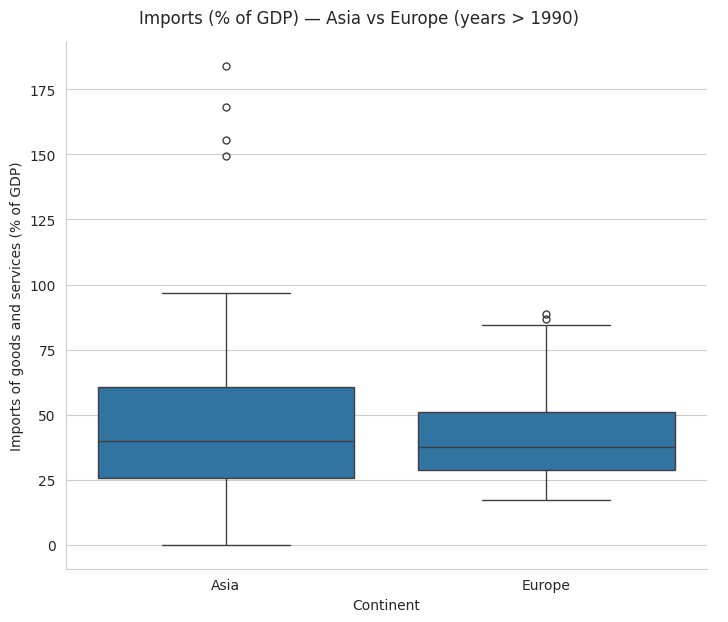

In [56]:
# Box catplot for the samples used in Shapiro-Wilk / Mann-Whitney tests
plot_df = df_asia_europe[['continent', 'Imports of goods and services (% of GDP)']].dropna()
sns.set_style('whitegrid')
g = sns.catplot(
    data=plot_df,
    x='continent',
    y='Imports of goods and services (% of GDP)',
    kind='box',
    order=['Asia', 'Europe'],
    height=6,
    aspect=1.2
)
g.set_axis_labels("Continent", "Imports of goods and services (% of GDP)")
g.fig.suptitle('Imports (% of GDP) — Asia vs Europe (years > 1990)', y=1.03)
plt.show()

3. What is the country (or countries) that has the highest `'Population density (people per sq. km of land area)'` across all years? (i.e., which country has the highest average ranking in this category across each time point in the dataset?)

In [57]:
df['Rank'] = df.groupby("Year")['Population density (people per sq. km of land area)'].rank(ascending=False)
df_sorted = df.sort_values(by=['Year', 'Rank'])
average_ranks = df.groupby('Country Name')['Rank'].mean()
top_stable_countries = average_ranks.sort_values().head(10)
print("Top 10 countries with high population density")
print(top_stable_countries)

Top 10 countries with high population density
Country Name
Monaco                        1.5
Macao SAR, China              1.5
Hong Kong SAR, China          3.1
Singapore                     3.9
Gibraltar                     5.0
Bermuda                       6.2
Malta                         7.0
Bangladesh                    9.2
Channel Islands               9.4
Sint Maarten (Dutch part)    10.5
Name: Rank, dtype: float64


4. What country (or countries) has shown the greatest increase in `'Life expectancy at birth, total (years)'` between 1962 and 2007? 

In [58]:
# filter years between 1962 and 2007
df_62_07 = df[(df['Year'] >= 1962) & (df['Year'] <= 2007)].copy()

# per-country min and max year
years = df_62_07.groupby('Country Name')['Year'].agg(min_year='min', max_year='max').reset_index()

# life expectancy at min year
life_min = (
    df_62_07.merge(years[['Country Name', 'min_year']],
                   left_on=['Country Name', 'Year'],
                   right_on=['Country Name', 'min_year'],
                   how='inner')
    [['Country Name', 'min_year', 'Life expectancy at birth, total (years)']]
    .drop_duplicates()
    .rename(columns={'Life expectancy at birth, total (years)': 'life_min'})
)

# life expectancy at max year
life_max = (
    df_62_07.merge(years[['Country Name', 'max_year']],
                   left_on=['Country Name', 'Year'],
                   right_on=['Country Name', 'max_year'],
                   how='inner')
    [['Country Name', 'max_year', 'Life expectancy at birth, total (years)']]
    .drop_duplicates()
    .rename(columns={'Life expectancy at birth, total (years)': 'life_max'})
)

# combine and compute duration and gain
result = (
    years
    .merge(life_min, on=['Country Name', 'min_year'], how='left')
    .merge(life_max, on=['Country Name', 'max_year'], how='left')
)

result['duration'] = result['max_year'] - result['min_year']
result['life_gain'] = result['life_max'] - result['life_min']
result['rate']=result['life_gain'] / result['duration']

# display
result = result.sort_values('life_gain', ascending=False).reset_index(drop=True)
result.head(10)

,Country Name,min_year,max_year,life_min,life_max,duration,life_gain,rate
0,Maldives,1962,2007,38.483561,75.399707,45,36.916146,0.820359
1,Bhutan,1962,2007,33.094146,66.293098,45,33.198951,0.737754
2,Timor-Leste,1962,2007,34.739049,65.824195,45,31.085146,0.690781
3,Tunisia,1962,2007,43.341683,74.202439,45,30.860756,0.685795
4,Oman,1962,2007,44.300512,75.123610,45,30.823098,0.684958
5,Nepal,1962,2007,35.952293,66.551927,45,30.599634,0.679992
6,China,1962,2007,44.398341,74.340439,45,29.942098,0.665380
7,"Yemen, Rep.",1962,2007,34.739561,61.954805,45,27.215244,0.604783
8,Saudi Arabia,1962,2007,46.694512,73.345073,45,26.650561,0.592235
9,"Iran, Islamic Rep.",1962,2007,46.065805,72.674195,45,26.608390,0.591298
